In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

/Users/tobiasmanwaring/Documents/UCL/Repos/Other/trTesting/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume,62_ma,91_ma,Strategy,Asset_Returns,Strategy_Returns
1,685.400024,685.400024,688.739990,678.130005,679.650024,127844500,681.553085,681.532988,-1.0,0.011541,-0.011541
2,688.979980,688.979980,691.130005,686.919983,689.849976,77112200,684.108999,684.070073,1.0,0.016825,-0.006378
3,689.229980,689.229980,690.960022,687.159973,688.150024,63059600,685.451847,685.402885,1.0,0.017193,-0.006018
4,692.729980,692.729980,694.130005,689.919983,690.489990,60473800,687.002874,686.933418,1.0,0.022359,-0.000970
5,695.489990,695.489990,696.530029,693.570007,694.179993,55506100,688.533880,688.439005,1.0,0.026432,0.003010
6,695.419983,695.419983,697.840027,693.940002,697.049988,61172200,689.615324,689.503233,1.0,0.026329,0.002909
7,694.039978,694.039978,697.059998,684.830017,696.390015,97486200,690.232829,690.114896,1.0,0.024292,0.000919
8,691.969971,691.969971,694.210022,687.119995,691.789978,101835100,690.451671,690.339595,1.0,0.021237,-0.002066
9,695.409973,695.409973,696.929993,689.419983,689.580017,79286500,691.022516,690.898232,1.0,0.026314,0.002895
10,689.530029,689.530029,696.960022,684.030029,696.210022,107904600,690.863912,690.759736,1.0,0.017636,-0.005585


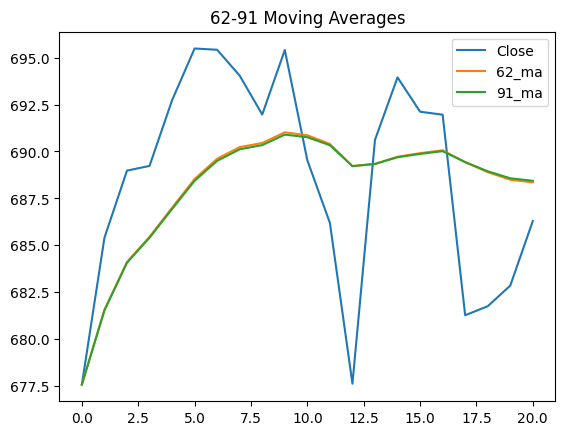

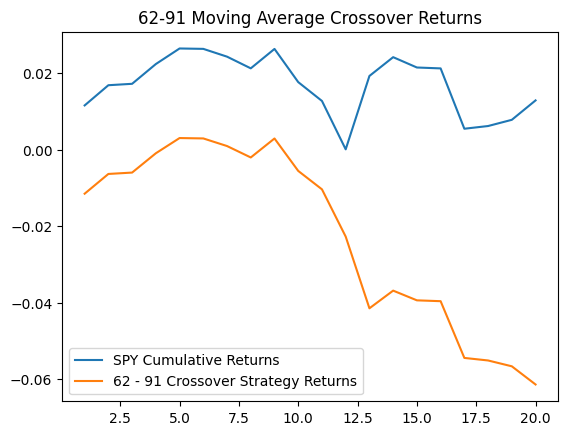

In [2]:
TICKER = 'SPY'
INTERVAL='1d'

if INTERVAL == '1h':
    PERIOD = '730d'
else:
    PERIOD = 'max'
LOOKBACK = 10000

FAST = 62
SLOW = 91

def get_data(ticker=TICKER, lookback=LOOKBACK, interval=INTERVAL):

    df = yf.download(ticker, interval=interval, auto_adjust=False)
    df.columns = df.columns.get_level_values(0)

    df = df.reset_index(drop=True)

    return df.iloc[-lookback:, :]

def add_moving_averages(df, fast, slow):
    df[f'{FAST}_ma'] = df['Close'].ewm(span=fast).mean()
    df[f'{SLOW}_ma'] = df['Close'].ewm(span=slow).mean()

    plt.plot(df['Close'])
    plt.plot(df[f'{FAST}_ma'])
    plt.plot(df[f'{SLOW}_ma'])
    plt.legend(['Close', f'{FAST}_ma', f'{SLOW}_ma'])
    plt.title(f'{FAST}-{SLOW} Moving Averages');
    return df.dropna()

def add_strategy(df, fast, slow):
    df['Strategy'] = np.where(df[f'{fast}_ma'] > df[f'{slow}_ma'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df

def test_strategy(df, ticker, fast, slow):
    df['Asset_Returns'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() -1

    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{ticker} Cumulative Returns', f'{fast} - {slow} Crossover Strategy Returns'])
    plt.title(f'{FAST}-{SLOW} Moving Average Crossover Returns'); 

    return df.dropna()

def main():
    df = get_data()
    df = add_moving_averages(df, FAST, SLOW)
    df = add_strategy(df, FAST, SLOW)
    df = test_strategy(df, TICKER, FAST, SLOW)

    return df

main()